Handling Imbalance Dataset

When dealing with imbalanced datasets, where one class significantly outnumbers the other(s), it can lead to biased models that perform poorly on the minority class. Here are some strategies to handle imbalanced datasets:   
1. Upsampling: This involves increasing the number of samples in the minority class by duplicating existing samples or generating synthetic samples using techniques like SMOTE (Synthetic Minority Over-sampling Technique).
2. Downsampling: This involves reducing the number of samples in the majority class by randomly removing samples until the classes are balanced.

In [2]:
import numpy as np
import pandas as pd

# Setting a random seed for reproducibility
np.random.seed(123)

# Creating a datafrome with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [4]:
n_class_0, n_class_1

(900, 100)

In [6]:
# Creating my dataframe with imbalanced dataset

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0,scale=1,size=n_class_0),
     'feature_2': np.random.normal(loc=0,scale=1,size=n_class_0), 
     'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0,scale=1,size=n_class_1),
     'feature_2': np.random.normal(loc=0,scale=1,size=n_class_1), 
     'target': [1] * n_class_1
})

In [8]:
df = pd.concat([class_0,class_1]).reset_index(drop=True)

In [9]:
df.head()

,feature_1,feature_2,target
0,-1.774224,0.285744,0
1,-1.201377,0.333279,0
2,1.096257,0.531807,0
3,0.861037,-0.354766,0
4,-1.520367,-1.120815,0


In [10]:
df.tail()

,feature_1,feature_2,target
995,0.677156,-0.907952,1
996,0.963404,-1.818045,1
997,-0.378524,-0.122733,1
998,1.429559,1.794486,1
999,1.532273,-0.320510,1


In [11]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [13]:
# Upsampling 

df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [14]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [15]:
df_minority_upsampled.shape

(900, 3)

In [16]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,0.905343,-0.504849,1
992,0.000977,-0.185167,1
914,-0.072043,0.280911,1
971,0.819483,0.964646,1
960,0.456515,-0.166472,1


In [17]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [19]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [20]:
# Downsampling

# Randomly reduce majority class to match minority class size
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

In [21]:
# Check class balance after downsampling
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64

### Explanation
- **Upsampling** duplicates (or synthetically creates) minority class samples until both classes are balanced.
- **Downsampling** removes majority class samples until both classes are balanced.
- Upsampling keeps all majority data but may increase overfitting risk.
- Downsampling is simple and fast but can discard useful information from the majority class.

### SMOTE (Synthetic Minority Over-sampling Technique)
SMOTE creates new minority-class samples by interpolating between existing minority samples. Instead of duplicating rows, it generates synthetic points in feature space, which can help reduce overfitting compared to naive upsampling.

**When to use:**
- You want more minority examples without throwing away majority data.
- Features are numeric or can be meaningfully interpolated.


In [22]:
from sklearn.datasets import make_classification

In [26]:
X,y = make_classification(n_samples=1000, n_features=2, n_clusters_per_class=1, weights=[0.90],random_state=27, n_redundant=0)


In [27]:
import pandas as pd
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,1.899073,-2.352325,0
1,0.074282,-0.161025,0
2,0.258625,-0.840895,0
3,1.481190,-1.677339,0
4,-0.187633,0.681020,0


In [28]:
final_df['target'].value_counts()

target
0    898
1    102
Name: count, dtype: int64

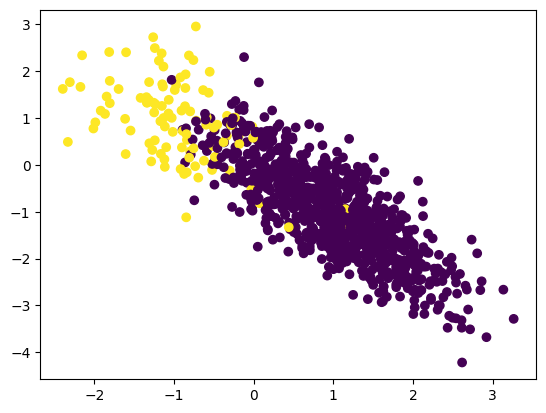

In [29]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [30]:
from imblearn.over_sampling import SMOTE

In [31]:
## transform the dataset using smote

oversample = SMOTE()
X,y = oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [32]:
X.shape

(1796, 2)

In [33]:
y.shape

(1796,)

In [35]:
len(y[y==0])

898

In [36]:
len(y[y==1])

898

In [37]:
df1 = pd.DataFrame(X,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,1.899073,-2.352325,0
1,0.074282,-0.161025,0
2,0.258625,-0.840895,0
3,1.481190,-1.677339,0
4,-0.187633,0.681020,0


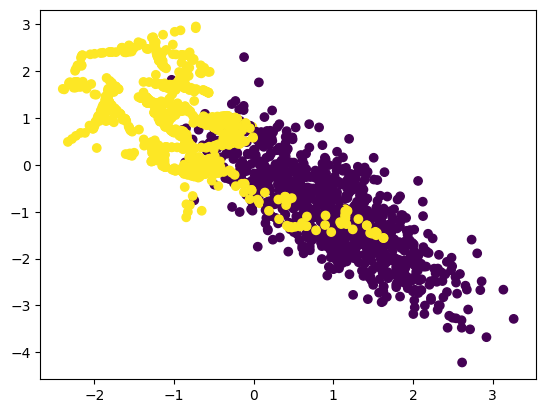

In [38]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])